In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import gc, os, re, time, zipfile
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aeroguard.pipeline import preparer
from aeroguard.decoupage import verifier_sans_fuite
from aeroguard.normalisation import CAPTEURS

DOSSIER = "/content/drive/MyDrive/aeroguard"
TRAVAIL = "/content/ncmapss"                      # disque temporaire de Colab
os.makedirs(TRAVAIL, exist_ok=True)
os.makedirs(f"{DOSSIER}/data/processed", exist_ok=True)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [2]:
!ls -lh {DOSSIER}/data/raw
!df -h /content

total 2.7G
-rw------- 1 root root 2.7G Sep 28 22:50 N-CMAPSS_DS01-005.h5
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [3]:
ZIP = f"{DOSSIER}/data/raw/data_set.zip"          # ← adapte le chemin si besoin

with zipfile.ZipFile(ZIP) as z:
    fichiers = sorted(n for n in z.namelist() if n.endswith(".h5"))

for f in fichiers:
    print(f)
print(len(fichiers), "fichiers")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/aeroguard/data/raw/data_set.zip'

In [4]:
!ls -lh /content/drive/MyDrive/aeroguard/data/raw
!find /content/drive/MyDrive -maxdepth 4 \( -name "*.zip" -o -name "*.h5" \) -exec ls -lh {} \;


total 2.7G
-rw------- 1 root root 2.7G Sep 28 22:50 N-CMAPSS_DS01-005.h5
-rw------- 1 root root 18K Jan  3  2025 '/content/drive/MyDrive/Examens Corrigés/Anciens Examens Java/Gestion Hopital.zip'
-rw------- 1 root root 5.6K Jan  3  2025 '/content/drive/MyDrive/Examens Corrigés/Anciens Examens Java/TDS14-main.zip'
-rw------- 1 root root 58K Jan  3  2025 '/content/drive/MyDrive/Examens Corrigés/Anciens Examens Java/Examen JAVA 3B 2021-2022LastVersion-.zip'
-rw------- 1 root root 2.7G Sep 28 22:50 /content/drive/MyDrive/aeroguard/data/raw/N-CMAPSS_DS01-005.h5


In [5]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [6]:
%cd /content
!wget -q --show-progress -O nasa.zip "https://phm-datasets.s3.amazonaws.com/NASA/17.+Turbofan+Engine+Degradation+Simulation+Data+Set+2.zip"
!ls -lh nasa.zip

/content
nasa.zip            100%[===================>]  14.68G  45.5MB/s    in 17m 42s 
-rw-r--r-- 1 root root 15G Sep 18  2022 nasa.zip


In [7]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   36G   73G  33% /


In [8]:
!unzip -o -q nasa.zip -d /content/nasa
!rm nasa.zip
!find /content/nasa \( -name "*.zip" -o -name "*.h5" \) -exec ls -lh {} \;
!df -h /content

-rw-r--r-- 1 root root 15G Sep 17  2022 '/content/nasa/17. Turbofan Engine Degradation Simulation Data Set 2/data_set.zip'
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   36G   73G  33% /


In [9]:
ZIP = "/content/nasa/17. Turbofan Engine Degradation Simulation Data Set 2/data_set.zip"

with zipfile.ZipFile(ZIP) as z:
    fichiers = sorted(n for n in z.namelist() if n.endswith(".h5"))

for f in fichiers:
    print(f)
print(len(fichiers), "fichiers")

data_set/N-CMAPSS_DS01-005.h5
data_set/N-CMAPSS_DS02-006.h5
data_set/N-CMAPSS_DS03-012.h5
data_set/N-CMAPSS_DS04.h5
data_set/N-CMAPSS_DS05.h5
data_set/N-CMAPSS_DS06.h5
data_set/N-CMAPSS_DS07.h5
data_set/N-CMAPSS_DS08a-009.h5
data_set/N-CMAPSS_DS08c-008.h5
data_set/N-CMAPSS_DS08d-010.h5
10 fichiers


In [12]:
# 1. Quel fichier pose problème ?
print("Fichier en cours :", chemin_zip)

# 2. Taille annoncée dans le zip vs taille extraite
!unzip -l "{ZIP}"
!ls -l {TRAVAIL}/data_set/

# 3. Le zip est-il intact ? (vérifie l'empreinte de chaque fichier)
!unzip -t "{ZIP}"

Fichier en cours : data_set/N-CMAPSS_DS08d-010.h5
Archive:  /content/nasa/17. Turbofan Engine Degradation Simulation Data Set 2/data_set.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2022-09-17 22:00   data_set/
2873351432  2021-01-13 16:00   data_set/N-CMAPSS_DS01-005.h5
2450472504  2021-01-13 16:21   data_set/N-CMAPSS_DS02-006.h5
3693395776  2021-01-13 11:53   data_set/N-CMAPSS_DS03-012.h5
3752493952  2021-01-13 16:53   data_set/N-CMAPSS_DS04.h5
2599166216  2021-01-12 12:29   data_set/N-CMAPSS_DS05.h5
2549159720  2021-01-13 15:12   data_set/N-CMAPSS_DS06.h5
2714714776  2021-01-13 15:34   data_set/N-CMAPSS_DS07.h5
3236762200  2021-01-13 17:21   data_set/N-CMAPSS_DS08a-009.h5
2413078176  2021-01-13 17:43   data_set/N-CMAPSS_DS08c-008.h5
2885034848  2021-01-13 18:00   data_set/N-CMAPSS_DS08d-010.h5
  4598892  2021-01-14 11:33   data_set/N-CMAPSS_Example_data_loading_and_exploration.ipynb
   857554  2021-01-14 11:32   data_set/Run_to_Failure_Simulat

In [13]:
!rm -rf {TRAVAIL}/data_set
!ls -lh {DOSSIER}/data/processed/vols_DS*.parquet

-rw------- 1 root root 638K Oct  4 11:05 /content/drive/MyDrive/aeroguard/data/processed/vols_DS01.parquet
-rw------- 1 root root 475K Oct  4 11:06 /content/drive/MyDrive/aeroguard/data/processed/vols_DS02.parquet
-rw------- 1 root root 781K Oct  4 11:08 /content/drive/MyDrive/aeroguard/data/processed/vols_DS03.parquet
-rw------- 1 root root 637K Oct  4 11:09 /content/drive/MyDrive/aeroguard/data/processed/vols_DS04.parquet
-rw------- 1 root root 592K Oct  4 11:10 /content/drive/MyDrive/aeroguard/data/processed/vols_DS05.parquet
-rw------- 1 root root 579K Oct  4 11:10 /content/drive/MyDrive/aeroguard/data/processed/vols_DS06.parquet
-rw------- 1 root root 588K Oct  4 11:11 /content/drive/MyDrive/aeroguard/data/processed/vols_DS07.parquet
-rw------- 1 root root 701K Oct  4 11:12 /content/drive/MyDrive/aeroguard/data/processed/vols_DS08a.parquet
-rw------- 1 root root 431K Oct  4 11:13 /content/drive/MyDrive/aeroguard/data/processed/vols_DS08c.parquet


In [14]:
EXCLUS = {"DS08d": "fichier tronqué dans le zip officiel NASA (données manquantes, A_dev illisible)"}

morceaux = []
for f in fichiers:
    nom = nom_court(f)
    if nom in EXCLUS:
        print(f"🚫 {nom} exclu : {EXCLUS[nom]}")
        continue
    morceaux.append(pd.read_parquet(f"{DOSSIER}/data/processed/vols_{nom}.parquet"))

vols = pd.concat(morceaux, ignore_index=True)
vols.to_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
print("Forme :", vols.shape, "| fichiers :", sorted(vols["dataset"].unique()))

groupes = [vols[vols["groupe"] == g].assign(unit=lambda d: d["moteur"]) for g in ["train", "val", "test"]]
print("Pas de fuite :", verifier_sans_fuite(*groupes))
print(vols.groupby("groupe")["moteur"].agg(moteurs="nunique", vols="size"))

🚫 DS08d exclu : fichier tronqué dans le zip officiel NASA (données manquantes, A_dev illisible)
Forme : (7473, 136) | fichiers : ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Pas de fuite : True
        moteurs  vols
groupe               
test         39  2938
train        49  3716
val          11   819


In [15]:
ds01 = vols[vols["dataset"] == "DS01"]
print("DS01 dev :", (ds01["groupe"] != "test").sum(), "vols | test :", (ds01["groupe"] == "test").sum(), "vols")

DS01 dev : 553 vols | test : 341 vols


In [16]:
par_mode = (vols.groupby("mode")
                .agg(fichiers=("dataset", lambda s: ", ".join(sorted(s.unique()))),
                     moteurs=("moteur", "nunique"),
                     vols=("moteur", "size"))
                .sort_values("vols"))
print(par_mode)

                         fichiers  moteurs  vols
mode                                            
LPC                          DS06        1    87
fan+LPC+HPC+HPT      DS08a, DS08c        2   134
fan+LPC+HPT+LPT      DS08a, DS08c        3   191
fan+LPC+HPC+LPT      DS08a, DS08c        3   194
LPC+HPC                      DS06        9   710
HPC                          DS05       10   818
fan                          DS04       10   856
fan+LPC+HPC+HPT+LPT  DS08a, DS08c       17  1028
LPT                    DS03, DS07       13  1044
HPT                    DS01, DS02       13  1140
HPT+LPT                DS02, DS03       18  1271


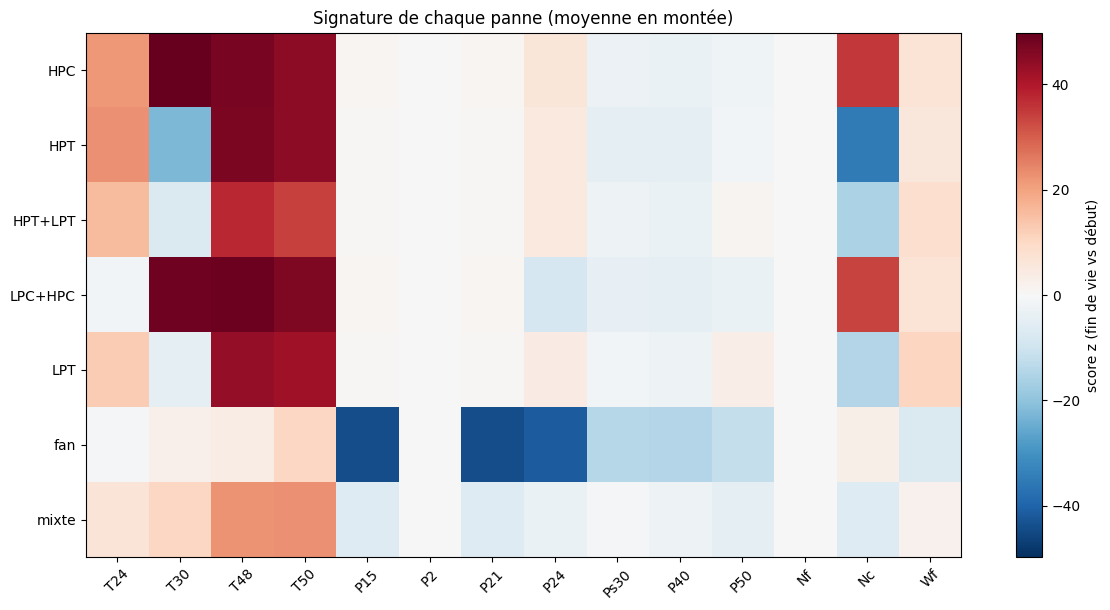

In [19]:
colonnes = [f"{c}_mean_montee" for c in CAPTEURS]
lignes = {}
for mode, m in vols.groupby("famille"):
    sains = m[m["cycle"] <= 10]
    uses = m[m["RUL"] <= 10]
    lignes[mode] = (uses[colonnes].mean() - sains[colonnes].mean()) / sains[colonnes].std()
signature = pd.DataFrame(lignes).T
signature.columns = CAPTEURS

limite = signature.abs().max().max()
plt.figure(figsize=(12, 0.6 * len(signature) + 2))
plt.imshow(signature, cmap="RdBu_r", vmin=-limite, vmax=limite, aspect="auto")
plt.colorbar(label="score z (fin de vie vs début)")
plt.xticks(range(len(CAPTEURS)), CAPTEURS, rotation=45)
plt.yticks(range(len(signature)), signature.index)
plt.title("Signature de chaque panne (moyenne en montée)")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/110_signatures_pannes.png", dpi=120)
plt.show()

In [18]:
def famille(mode):
    if mode.startswith("fan+"):
        return "mixte"            # DS08 : plusieurs pièces abîmées en même temps
    if mode == "LPC":
        return "LPC+HPC"          # cas limite : même famille que DS06
    return mode

vols["famille"] = vols["mode"].map(famille)
vols.to_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
print(vols.groupby("famille")["moteur"].agg(moteurs="nunique", vols="size").sort_values("vols"))

         moteurs  vols
famille               
LPC+HPC       10   797
HPC           10   818
fan           10   856
LPT           13  1044
HPT           13  1140
HPT+LPT       18  1271
mixte         25  1547
